# **Project Name**    - Airbnb Booking Analysis

##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Name** - Amit Kumar Das


# **Business Problem & Objective**

The Airbnb marketplace lacks clear visibility into the key factors driving pricing, availability, and listing performance across different neighborhoods. This creates challenges for both hosts (in optimizing pricing and occupancy) and travelers (in finding cost-effective, high-value stays).

As a Business Analyst, the objective of this project is to:




*   Identify key drivers of price variation (e.g., location, room type, minimum nights, host activity)
*   Analyze availability and demand patterns across neighborhoods


*  Uncover data-driven insights that help hosts optimize pricing and improve occupancy

* Enable Airbnb to make strategic decisions around pricing guidance, host engagement, and market expansion

By transforming raw data into actionable insights, this analysis supports better decision-making for hosts, improved user experience for travelers, and overall platform growth.

# **GitHub Link -**

https://github.com/Amitkumardas123/Capstone-project---Airbnb-booking-analysis

# **Problem Statement**


Airbnb is an online marketplace that connects people who want to rent out their property with people who are looking for accommodations, typically for short stays. we will analyze the relationship between  different different variable

1.Find top 5 hosts who have most number of property according their areas?

2.Which host charging highest price/day according room type?

3.Finding room type  and their avg price according their araes?

4.Most prefered room type in terms of price?

5.Find top 10 busiest host and its reason?

6.Number of active host per location?

7.Most prfered area by customer according reviews?

8.Total reviews by each neighbourhood group using pie chart?

9.What is the room count in overall dataset according to the listing of room type?

10.Find reviews trend per month according neighbourhood group?

11.Stay reqirements counts by minimum nights?

12.Find Avg room avilability days of each neighbourhood Group?


# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

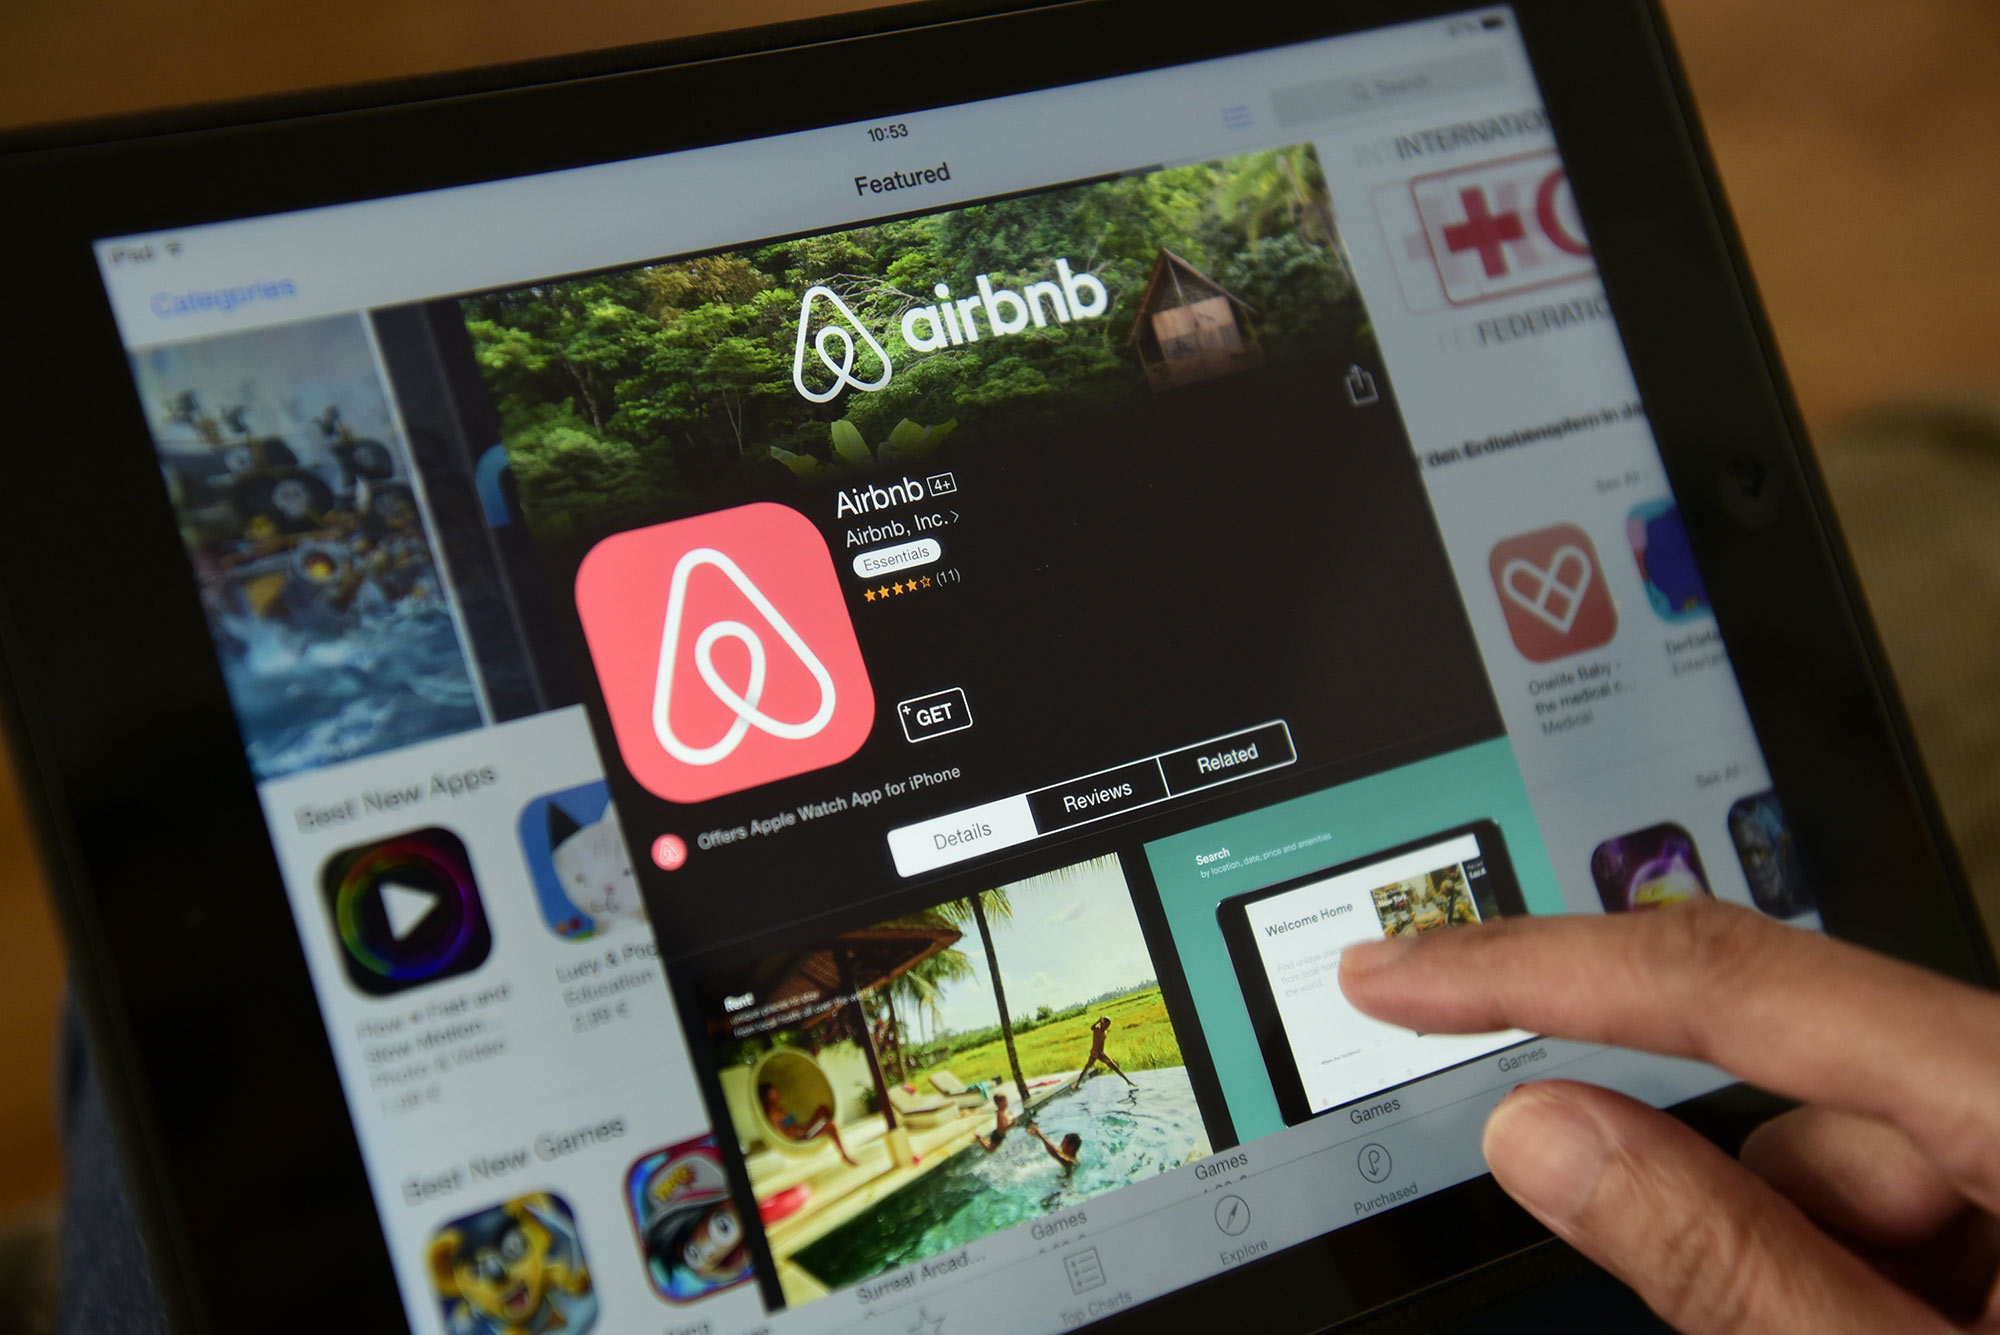

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
from datetime import datetime
from numpy import math

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

### Dataset Loading

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load Dataset
Airbnb_df = pd.read_csv('/content/drive/MyDrive/Full Stack Data Science/Python Programming/Capstone project EDA/Airbnb NYC 2019.csv')

### Dataset First View

In [ ]:
# Dataset First Look
Airbnb_df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count
Airbnb_df.shape

(48895, 16)

### Dataset Information

In [ ]:
# Dataset Info
Airbnb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

#### Duplicate Values

In [ ]:
# Remove Duplicate Value in Dataset
Airbnb_df.drop_duplicates(inplace=True)

In [ ]:
Airbnb_df.shape

(48895, 16)

Dataframe shape remain same that means there is no duplicate values in our Dataset

#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
Airbnb_df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [ ]:
# Visualizing the missing values

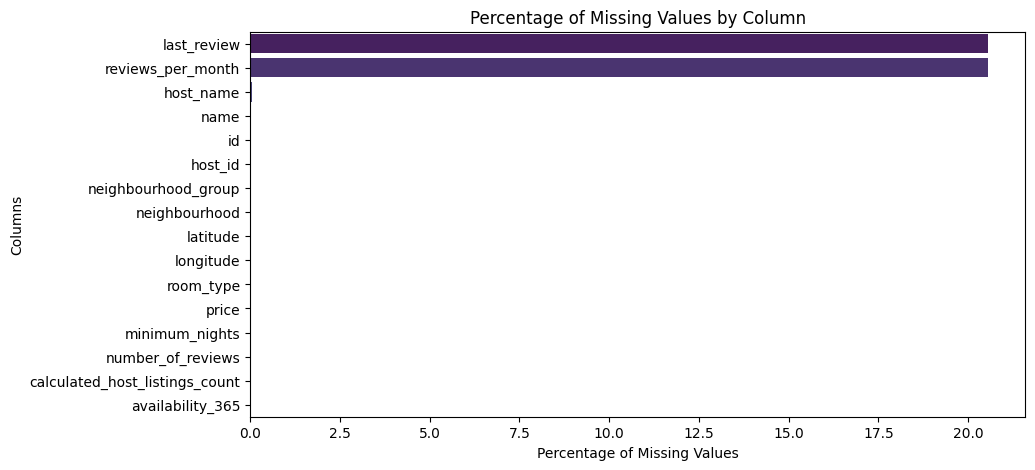

In [ ]:
# Calculate the percentage of missing values in each column
missing_percentage = (Airbnb_df.isnull().mean() * 100).sort_values(ascending=False)
# Create a bar chart
plt.figure(figsize=(10, 5))
sns.barplot(x=missing_percentage, y=missing_percentage.index, palette='viridis')
plt.xlabel('Percentage of Missing Values')
plt.ylabel('Columns')
plt.title('Percentage of Missing Values by Column')
plt.show()

### What did you know about your dataset?

This is a Airbnb booking analysis data(2011 - 2019).This data find includes all needed information to find out more about hosts,geographically availabilility,necessary metrics to make predictions and draw visulization.

The above dataset has 48895 rows and 16 columns. There are some  mising values are present and have no duplicate values in the dataset.

```
# This is formatted as code
```



## ***2. Understanding Your Variables***

id :- This is a unique identifier for each listing in the dataset.

name :- This is the name or title of the listing, as it appears on the Airbnb website.

Host_id :- This is a unique identifier for each host in the dataset.

Host_name :- This is the name of the host as it appears on the Airbnb website.

Neighbourhood_group :- This is a grouping of neighborhoods in New York City, such as Manhattan or Brooklyn.

Neighbourhood :- This is the specific neighborhood in which the listing is located.

Latitude :- This is the geographic latitude of the listing.

Longitude :- This is the geographic longitude of the listing.

Room_type :- This is the type of room or property being offered, such as an entire home, private room, shared room.

Price :- This is the nightly price for the listing, in US dollars.

Minimum_nights :- This is the minimum number of nights that a guest must stay at the listing.

Total_reviews :- This is the total number of reviews that the listing has received.

Reviews_per_month :- This is the average number of reviews that the listing receives per month.

Host_listings_count :- This is the total number of listings that the host has on Airbnb.

Availability_365 :- This is the number of days in the next 365 days that the listing is available for booking.

In [ ]:
# Dataset Columns
Airbnb_df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

# **Dropping unnecessary columns**

In [ ]:
Airbnb_df.drop(['latitude','longitude'],axis=1,inplace=True)

In [ ]:
Airbnb_df.head(2)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,Entire home/apt,225,1,45,2019-05-21,0.38,2,355


In [ ]:
# Dataset Describe
Airbnb_df.describe()

,id,host_id,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable.
unique_value_var = Airbnb_df.apply(lambda col: col.unique())
unique_value_var


id                                [2539, 2595, 3647, 3831, 5022, 5099, 5121, 517...
name                              [Clean & quiet apt home by the park, Skylit Mi...
host_id                           [2787, 2845, 4632, 4869, 7192, 7322, 7356, 896...
host_name                         [John, Jennifer, Elisabeth, LisaRoxanne, Laura...
neighbourhood_group               [Brooklyn, Manhattan, Queens, Staten Island, B...
neighbourhood                     [Kensington, Midtown, Harlem, Clinton Hill, Ea...
room_type                              [Private room, Entire home/apt, Shared room]
price                             [149, 225, 150, 89, 80, 200, 60, 79, 135, 85, ...
minimum_nights                    [1, 3, 10, 45, 2, 5, 4, 90, 7, 14, 60, 29, 30,...
number_of_reviews                 [9, 45, 0, 270, 74, 49, 430, 118, 160, 53, 188...
last_review                       [2018-10-19, 2019-05-21, nan, 2019-07-05, 2018...
reviews_per_month                 [0.21, 0.38, nan, 4.64, 0.1, 0.59, 0.4, 3.

In [ ]:
unique_value_var[4:5].values

array([array(['Brooklyn', 'Manhattan', 'Queens', 'Staten Island', 'Bronx'],
             dtype=object)                                                 ],
      dtype=object)

## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
# Write your code to make your dataset analysis ready.
Airbnb_df.fillna({'name':'not present','host_name':'absent','last_review':'not given','reviews_per_month':0},inplace=True)

In [ ]:
Airbnb_df.isnull().sum()

id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

In [ ]:
#check extremly low value in price coloumn and availability_365
Airbnb_df[(Airbnb_df['price'] == 0) & (Airbnb_df['availability_365'] != 0)]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
23161,18750597,"Huge Brooklyn Brownstone Living, Close to it all.",8993084,Kimberly,Brooklyn,Bedford-Stuyvesant,Private room,0,4,1,2018-01-06,0.05,4,28
25433,20333471,★Hostel Style Room | Ideal Traveling Buddies★,131697576,Anisha,Bronx,East Morrisania,Private room,0,2,55,2019-06-24,2.56,4,127
25778,20624541,Modern apartment in the heart of Williamsburg,10132166,Aymeric,Brooklyn,Williamsburg,Entire home/apt,0,5,3,2018-01-02,0.15,1,73
25794,20639628,Spacious comfortable master bedroom with nice ...,86327101,Adeyemi,Brooklyn,Bedford-Stuyvesant,Private room,0,1,93,2019-06-15,4.28,6,176
25795,20639792,Contemporary bedroom in brownstone with nice view,86327101,Adeyemi,Brooklyn,Bedford-Stuyvesant,Private room,0,1,95,2019-06-21,4.37,6,232
25796,20639914,Cozy yet spacious private brownstone bedroom,86327101,Adeyemi,Brooklyn,Bedford-Stuyvesant,Private room,0,1,95,2019-06-23,4.35,6,222
26841,21291569,Coliving in Brooklyn! Modern design / Shared room,101970559,Sergii,Brooklyn,Bushwick,Shared room,0,30,2,2019-06-22,0.11,6,333
26866,21304320,Best Coliving space ever! Shared room.,101970559,Sergii,Brooklyn,Bushwick,Shared room,0,30,5,2019-05-24,0.26,6,139


In [ ]:
# exclude the price data which value is 0
Airbnb_df = Airbnb_df.loc[Airbnb_df['price']>0]

In [ ]:
Airbnb_df.shape

(48884, 14)

In [ ]:
Airbnb_df.describe()

,id,host_id,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.888400e+04,4.888400e+04,48884.000000,48884.000000,48884.000000,48884.000000,48884.000000,48884.000000
mean,1.901679e+07,6.762203e+07,152.755053,7.029887,23.271991,1.090800,7.144628,112.779498
std,1.098432e+07,7.861666e+07,240.170260,20.512224,44.551331,1.597213,32.956185,131.627271
min,2.539000e+03,2.438000e+03,10.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,9.470548e+06,7.817310e+06,69.000000,1.000000,1.000000,0.040000,1.000000,0.000000
50%,1.967574e+07,3.079257e+07,106.000000,3.000000,5.000000,0.370000,1.000000,45.000000
75%,2.915297e+07,1.074344e+08,175.000000,5.000000,24.000000,1.580000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


### What all manipulations have you done and insights you found?

When we analyze the data  we found  that there are some value in price and availability_365 column is equals to 0 so we needto exclude this value other wise it will impact our business model.And talk to the person who will handel this.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

# 1.Find top 5 different hosts who have most number of property according there areas?

In [ ]:
# Chart - 1 visualization code
Host_area = Airbnb_df.groupby(['host_name','neighbourhood_group'])['calculated_host_listings_count'].max().reset_index().sort_values(by='calculated_host_listings_count', ascending=False).head(5)

Host_area['Hostname_according_area'] = Host_area['host_name']+'\n'+Host_area['neighbourhood_group']

Text(0.5, 1.0, 'Number of listing room according their hosts')

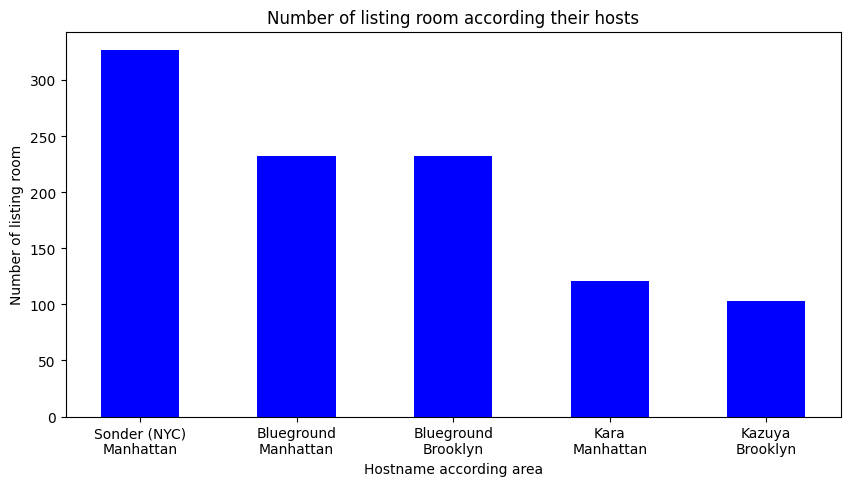

In [ ]:
#visulize the data
Area = Host_area['Hostname_according_area']
host_count = Host_area['calculated_host_listings_count']

plt.rcParams['figure.figsize'] = (10,5)
plt.bar(Area,host_count,color= 'blue',width = 0.5)
plt.xlabel('Hostname according area')
plt.ylabel('Number of listing room')
plt.title('Number of listing room according their hosts')

##### 1. Why did you pick the specific chart?

Bar chart usually use to check how a particular variable varies across different type of another variable thats why i choose this bar chart

##### 2. What is/are the insight(s) found from the chart?



*   We can see most number of listing from Manhattan in the name of Sonder(nyc)then Blueground and Kara. secondly in Brooklyn in the name of Blueground and Kazuya.Thats mean this people has most number of property to be used an Airbnb

*   A small number of hosts dominate listings in specific areas.
*   Indicates market concentration (possible commercial hosts vs individual hosts).

# **Business Recommendation:**

*   Airbnb should monitor high-volume hosts to ensure quality standards and avoid platform misuse.

*   Introduce host-tier programs (e.g., Super Host Pro) for large hosts to maintain consistency.
*   Encourage new hosts in those areas to reduce dependency on a few players → improves competition and pricing balance.

# 2.Which host charging highest price/day according room type?

In [ ]:
Airbnb_df['Daily_charge'] = Airbnb_df['price'] / Airbnb_df['minimum_nights']
Airbnb_df.head(5)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,Daily_charge
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,Private room,149,1,9,2018-10-19,0.21,6,365,149.0
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,225.0
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,Private room,150,3,0,not given,0.00,1,365,50.0
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,89.0
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,8.0


In [ ]:
# Chart - 2 visualization code
price = Airbnb_df.groupby(['host_name','room_type'])['Daily_charge'].max().reset_index()
price['Hostname_according_charge'] = price['host_name']+'\n'+price['room_type']
Price_= price.sort_values(by='Daily_charge',ascending = False).head(10)
Price_

,host_name,room_type,Daily_charge,Hostname_according_charge
6212,Jessica,Entire home/apt,8000.0,Jessica\nEntire home/apt
11670,Sally,Entire home/apt,7703.0,Sally\nEntire home/apt
5741,Jack,Entire home/apt,7500.0,Jack\nEntire home/apt
11752,Sandra,Private room,7500.0,Sandra\nPrivate room
7186,Kevin,Entire home/apt,6800.0,Kevin\nEntire home/apt
6474,Jonathan,Entire home/apt,6500.0,Jonathan\nEntire home/apt
7901,Linda,Entire home/apt,6000.0,Linda\nEntire home/apt
10321,Omri,Entire home/apt,5250.0,Omri\nEntire home/apt
11004,Rasmus,Entire home/apt,5000.0,Rasmus\nEntire home/apt
518,Alissa,Entire home/apt,5000.0,Alissa\nEntire home/apt


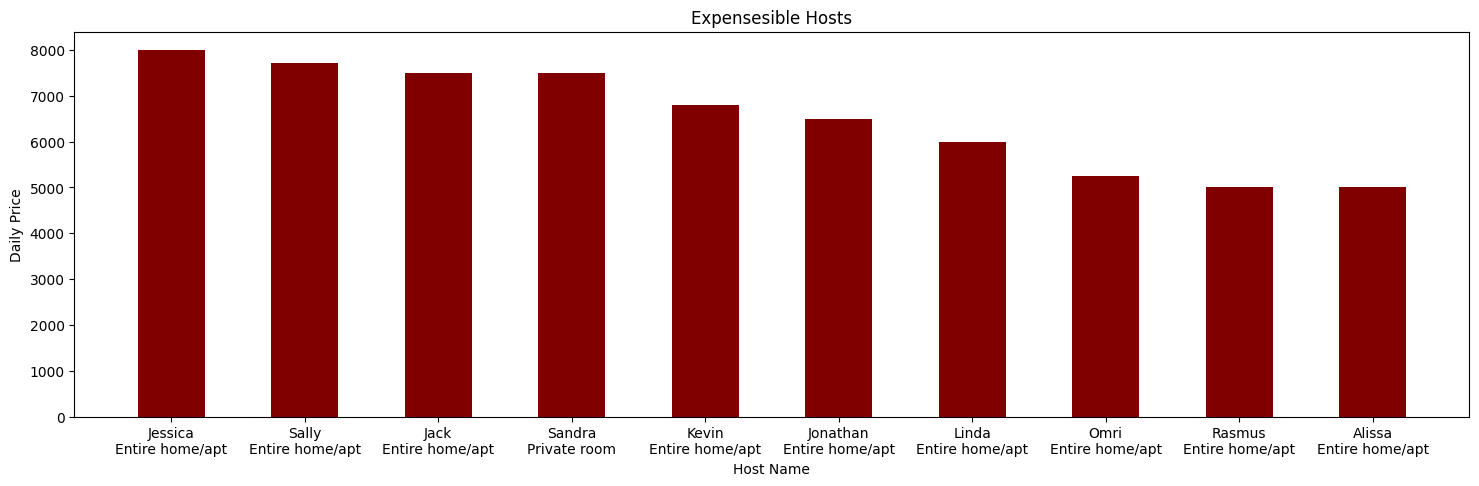

In [ ]:
Hosts= Price_['Hostname_according_charge']
Prise = Price_['Daily_charge']

plt.rcParams['figure.figsize'] = (18,5)
plt.bar(Hosts,Prise, color ='maroon',
        width = 0.5)

plt.xlabel("Host Name")
plt.ylabel("Daily Price")
plt.title("Expensesible Hosts")
plt.show()


# **Insight**:

*   From the above analysis we found that most charging property listed as Entire home/apt And private room.Its mean Entire home/apt and private room rent was so high as comare to other rooms
*   Certain hosts charge premium prices for specific room types (likely entire homes).

*   Pricing varies significantly across hosts → no standard pricing benchmark.

# **Business Recommendation:**

*   Airbnb can introduce AI-based pricing suggestions for hosts to stay competitive.

*   Highlight premium listings as “Luxury stays” to attract high-value customers.

*   For overpriced listings with low bookings → suggest dynamic discounting strategies.




# 3.Finding room type and their average price according their areas?


In [ ]:
# Chart - 3 visualization code
price_area= Airbnb_df.groupby(['neighbourhood_group','room_type'])['price'].mean().unstack()
price_area.head()

room_type,Entire home/apt,Private room,Shared room
neighbourhood_group,,,
Bronx,127.506596,66.890937,59.800000
Brooklyn,178.346202,76.545428,50.773723
Manhattan,249.257994,116.776622,88.977083
Queens,147.050573,71.762456,69.020202
Staten Island,173.846591,62.292553,57.444444


Text(0, 0.5, 'Average price')

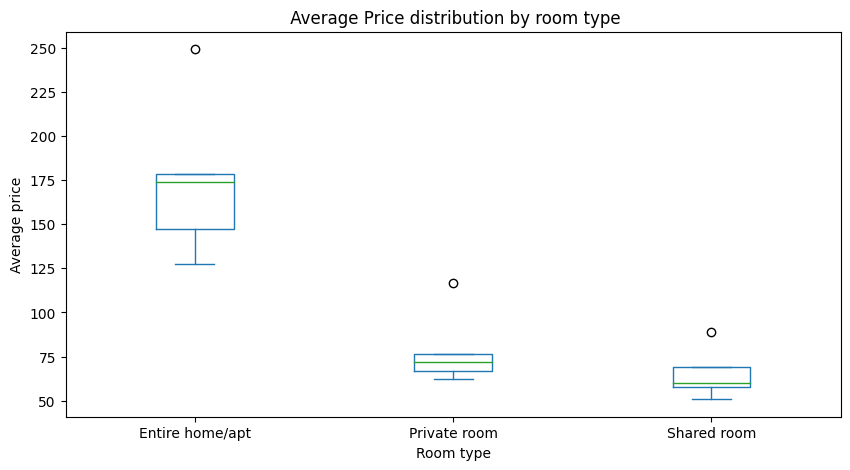

In [ ]:
# visualize the ditribution of average price
plt.rcParams['figure.figsize'] = (10,5)
price_area.plot(kind= "box")
plt.title(' Average Price distribution by room type')
plt.xlabel('Room type')
plt.ylabel('Average price')

##### 1. Why did you pick the specific chart?

We want to see the range of distribution of average price of different room type according to area.Box or  whisker plot help us to analyze the data in total 5 number of summary

.Lower whisker(Q1 - 1.5*IQR)

.Q1 - Fast quartile or 25%

.Q2 - Median or 50%

.Q3 - Third quartile or 75%

.Upper whisker (Q3 + 1.5*IQR)

IQR = (Q3 - Q1)

and there is some value outside its range called Outlier.


##### 2. What is/are the insight(s) found from the chart?

*    From tthe above chart we found that the upper half of your datain price column is relatively evenly distributed, and there are no significant outliers in the upper range of your data. In other words, most of the highest 25% of your data values in price column are very close to Q3.

*   Entire homes are consistently more expensive than private/shared rooms.
*   Some areas show unusually high prices → likely high demand zones.



# **Business Recommendation:**

*   Promote budget room types (private/shared) in high-price areas to attract cost-sensitive travelers.

*   Help hosts in expensive areas optimize pricing using demand-based pricing tools.
*   Airbnb can target these areas for premium marketing campaigns (tourist hotspots).

# 4.Most prefered room type in terms of price and reviews ?

In [ ]:
# Chart - 5 visualization code
preferd_room = Airbnb_df.groupby(['room_type','price'])['number_of_reviews'].max().reset_index()
preferd_room.head()

,room_type,price,number_of_reviews
0,Entire home/apt,10,93
1,Entire home/apt,11,113
2,Entire home/apt,12,0
3,Entire home/apt,15,0
4,Entire home/apt,16,21


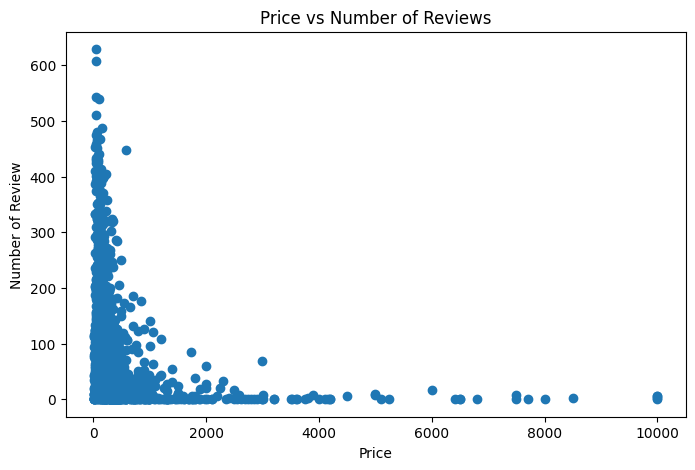

In [ ]:
area = preferd_room['price']
Reviews = preferd_room['number_of_reviews']

plt.rcParams['figure.figsize'] = (8,5)

# creating the bar plot
plt.scatter(area, Reviews)

plt.xlabel("Price")
plt.ylabel("Number of Review")
plt.title("Price vs Number of Reviews")
plt.show()

##### 1. Why did you pick the specific chart?

Plotting a scattergram with my data points can help me to determine whether there's a potential relationship between them.

##### 2. What is/are the insight(s) found from the chart?

*   From the above Analysis we can say that most people prefer to stay in entire home/apt where price is less.
*   Listings with lower prices tend to receive more reviews, indicating higher booking frequency, while higher-priced listings show lower engagement.





# **Business Recommendation:**

Airbnb should encourage hosts to adopt competitive pricing strategies and provide price benchmarking tools to improve booking volume and visibility.

# 5.Find top 10 busiest hosts and its reason?

In [ ]:
Busy_host = Airbnb_df.groupby(['host_name','room_type'])['number_of_reviews'].max().reset_index()
busy_hosts = Busy_host.sort_values(by='number_of_reviews', ascending=False).head(10)
busy_hosts

,host_name,room_type,number_of_reviews
3433,Dona,Private room,629
6332,Jj,Private room,607
8977,Maya,Private room,543
2163,Carol,Private room,540
2974,Danielle,Private room,510
1214,Asa,Entire home/apt,488
13839,Wanda,Private room,480
7902,Linda,Private room,474
2946,Dani,Entire home/apt,467
863,Angela,Private room,466


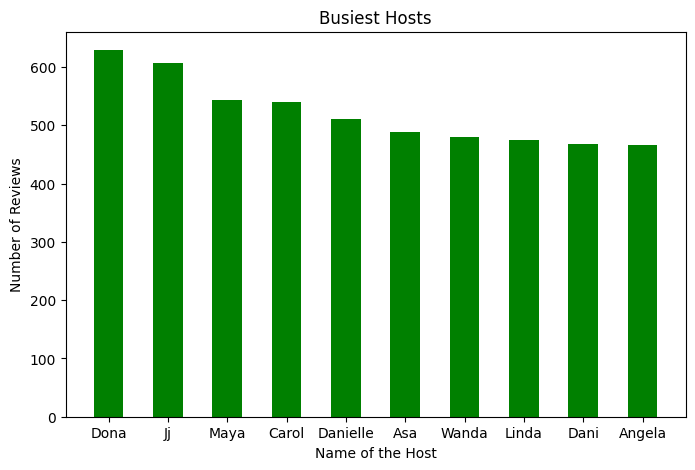

In [ ]:
# Chart - 3 visualization code
name = busy_hosts['host_name']
reviews = busy_hosts['number_of_reviews']

plt.bar(name, reviews, color ='green',
        width = 0.5)
plt.xlabel("Name of the Host")
plt.ylabel("Number of Reviews")
plt.title("Busiest Hosts")
plt.show()


##### 2. What is/are the insight(s) found from the chart?

##Busiest hosts are:
1. Dona
2. Ji
3. Maya
4. Carol
5. Danielle

##Because these hosts listed room type as Entire home and Private room which is preferred by most number of people.which price is less

# 6.Number Of Active Hosts Per Location

In [ ]:
#Group data by neighbourhood group and id
hosts_per_location = Airbnb_df.groupby('neighbourhood_group')['id'].count()
hosts_per_location

neighbourhood_group
Bronx             1090
Brooklyn         20095
Manhattan        21660
Queens            5666
Staten Island      373
Name: id, dtype: int64

Text(0, 0.5, 'Number of Active Hosts')

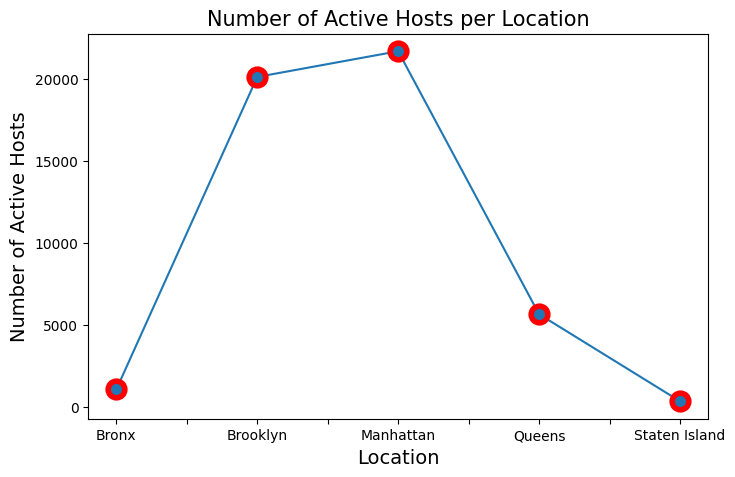

In [ ]:
# Create the line chart with some experiments using marker function
hosts_per_location.plot( marker='o', ms=12, mew=4, mec='r')
plt.title('Number of Active Hosts per Location', fontsize='15')
plt.xlabel('Location', fontsize='14')
plt.ylabel('Number of Active Hosts', fontsize='14')

Manhattan has the largest number of hosts with  21660,Brooklyn has the second largest number of hosts with 20095.

After that Queens with 5666 and the Bronx with 1090. while Staten Island has the fewest with 373.
Availability varies significantly across neighborhoods, with some areas showing low availability (high demand) and others high availability (low demand).

# **Business Recommendation:**
*   Increase host acquisition in high-demand areas
*   Offer promotions or discounts in low-demand areas to balance supply-demand

# 7.Most prefered area by customer according reviews?

In [ ]:
# Group the Airbnb data by neighbourhood group
reviews_by_neighbourhood_group = Airbnb_df.groupby("neighbourhood_group")["number_of_reviews"].max()
reviews_by_neighbourhood_group


neighbourhood_group
Bronx            321
Brooklyn         488
Manhattan        607
Queens           629
Staten Island    333
Name: number_of_reviews, dtype: int64

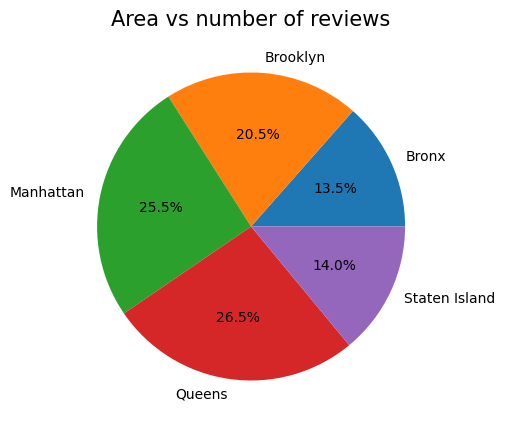

In [ ]:
# Create a pie chart to visualize the distribution of maximum number of reviews among different neighbourhood groups
plt.pie(reviews_by_neighbourhood_group, labels=reviews_by_neighbourhood_group.index, autopct='%1.1f%%')

# Add a title to the chart
plt.title("Area vs number of reviews", fontsize='15')
plt.show()

##### 2. What is/are the insight(s) found from the chart?

From the above visualization we found that most of the poeople prefered to stay Queens, then Manhattan, then Brooklyn ,then State island and then Bronx

# 8.Total Reviews by Each Neighborhood Group using Pie Chart

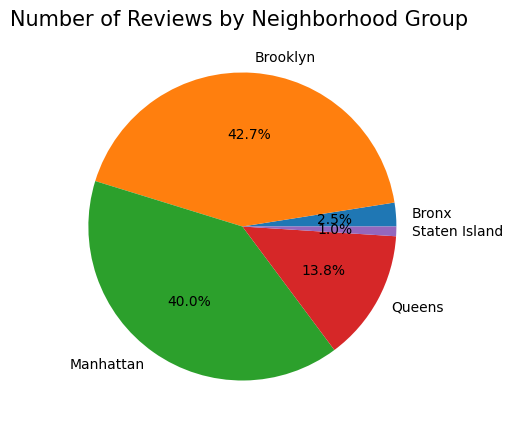

In [ ]:
# Group the data by neighborhood group and calculate the total number of reviews
reviews_by_neighbourhood_group = Airbnb_df.groupby("neighbourhood_group")["number_of_reviews"].sum()

# Create a pie chart
plt.pie(reviews_by_neighbourhood_group, labels=reviews_by_neighbourhood_group.index, autopct='%1.1f%%')
plt.title("Number of Reviews by Neighborhood Group ", fontsize='15')

# Display the chart
plt.show()


##### 2. What is/are the insight(s) found from the chart?

 From the above chart we found that Brooklyn has the largest share of total reviews on Airbnb, with 42.7%, followed by Manhattan with 40.0%.

Queens has the third largest share of total reviews, with 13.8%, followed by the Bronx with 2.5% and Staten Island with 1.0%.

The data suggests that Airbnb is more popular in Brooklyn and Manhattan compared to the other neighborhood groups.


# 9.What is the room count in overall dataset according to the listing of room type

Text(0.5, 1.0, 'Total Room availble in different area')

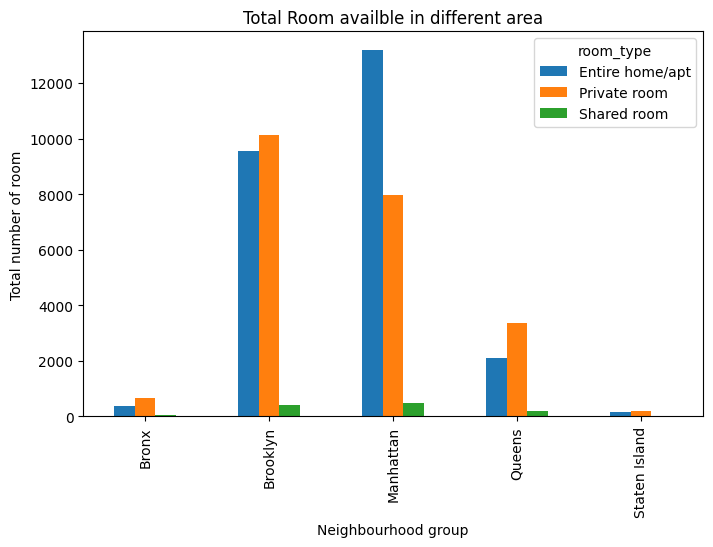

In [ ]:
Room_count = Airbnb_df.groupby(['neighbourhood_group'])['room_type'].value_counts().unstack()
Room_count.plot(kind ='bar')
plt.xlabel('Neighbourhood group')
plt.ylabel('Total number of room')
plt.title('Total Room availble in different area')

##### 2. What is/are the insight(s) found from the chart?

We found that Manhattan have listed most number of entire room/apt and then Brooklyn,Queens,Bronx,Staten island respectively.but in case of Private room Brooklyn  has highest number of room then Manhattan,Queens,Bronx,Staten islandrespectively

# 10.Find  popularity of Airbnb booking among people or guest According year and neighbourhood group?

In [ ]:
Airbnb_df['review_month'] = Airbnb_df['last_review'].str[0:4]
Airbnb_df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,review_month
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,Private room,149,1,9,2018-10-19,0.21,6,365,2018
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,2019
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,Private room,150,3,0,not given,0.00,1,365,not
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,2019
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,2018


In [ ]:
df = Airbnb_df[Airbnb_df['review_month']!= 'not ']
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,review_month
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,Private room,149,1,9,2018-10-19,0.21,6,365,2018
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,2019
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,2019
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,2018
5,5099,Large Cozy 1 BR Apartment In Midtown East,7322,Chris,Manhattan,Murray Hill,Entire home/apt,200,3,74,2019-06-22,0.59,1,129,2019


In [ ]:
df.shape

(38833, 15)

Text(0, 0.5, 'Reviews')

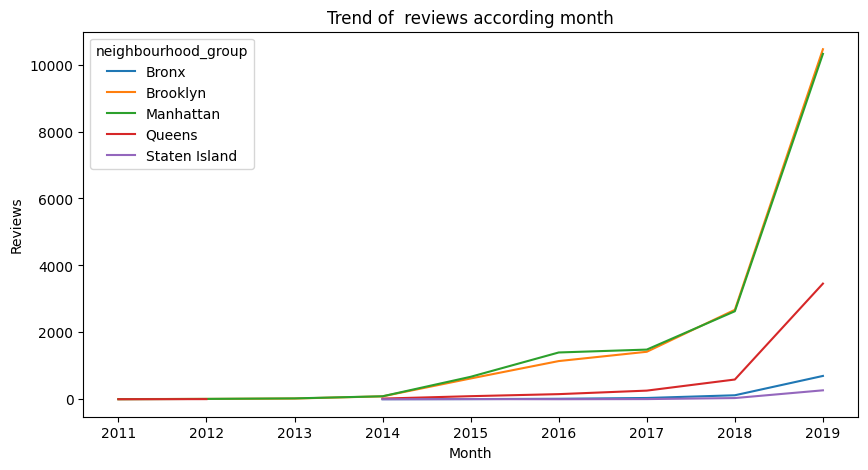

In [ ]:
Monthly_review = df.groupby(['review_month','neighbourhood_group'])['reviews_per_month'].count().unstack()
Monthly_review.plot()
plt.title('Trend of  reviews according month')
plt.xlabel('Month')
plt.ylabel('Reviews')

From the above chart we found that till 2014 less people using Airbnb booking app thats why review is less.After 2014 the trend of booking is slowly slowly increase and after 2018 the trend is increasing fast thats mean after 2018 large number of people use Airbnb for booking.

#11.Stay Requirement counts by Minimum Nights.

In [ ]:
# Group the DataFrame by the minimum_nights column and count the number of rows in each group
minimum_nights_counts = Airbnb_df['minimum_nights'].value_counts().reset_index()
minimum_nights_counts.columns = ['minimum_nights', 'count']

minimum_nights_counts = minimum_nights_counts.head(15)

minimum_nights_counts

,minimum_nights,count
0,1,12717
1,2,11693
2,3,7998
3,30,3758
4,4,3302
5,5,3033
6,7,2058
7,6,752
8,14,562
9,10,483


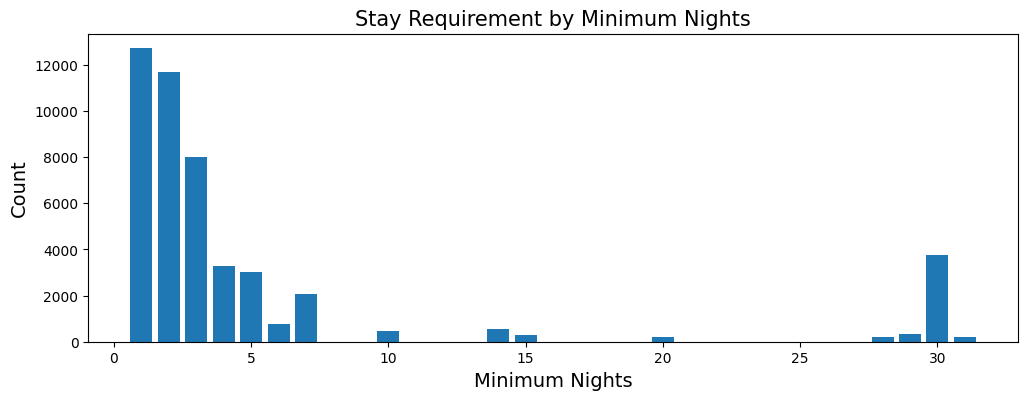

In [ ]:
minimum_nights = minimum_nights_counts['minimum_nights']
count = minimum_nights_counts['count']

# Set the figure size
plt.figure(figsize=(12, 4))

# Create the bar plot
plt.bar(minimum_nights, count)

# Add axis labels and a title
plt.xlabel('Minimum Nights', fontsize='14')
plt.ylabel('Count', fontsize='14')
plt.title('Stay Requirement by Minimum Nights', fontsize='15')

# Show the plot
plt.show()

The majority of listings on Airbnb have a minimum stay requirement of 1 or 2 nights, with 12717 and 11693 listings, respectively.

The number of listings with a minimum stay requirement decreases as the length of stay increases, with 7998 listings requiring a minimum stay of 3 nights, and so on.

There are relatively few listings with a minimum stay requirement of 30 nights or more, with 3758 and 201 listings, respectively.

Listings with higher minimum night requirements tend to have fewer reviews, suggesting reduced booking flexibility lowers demand.

# **Business Recommendation:**

Airbnb should recommend optimal minimum stay thresholds (e.g., 1–3 nights) to improve booking conversion rates.

# 12.Find average room availability days of each neighbourhood group?

In [ ]:
#Describe ourdatset
Airbnb_df.describe()

,id,host_id,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,Daily_charge
count,4.888400e+04,4.888400e+04,48884.000000,48884.000000,48884.000000,48884.000000,48884.000000,48884.000000,48884.000000
mean,1.901679e+07,6.762203e+07,152.755053,7.029887,23.271991,1.090800,7.144628,112.779498,70.190038
std,1.098432e+07,7.861666e+07,240.170260,20.512224,44.551331,1.597213,32.956185,131.627271,157.634605
min,2.539000e+03,2.438000e+03,10.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.040000
25%,9.470548e+06,7.817310e+06,69.000000,1.000000,1.000000,0.040000,1.000000,0.000000,20.000000
50%,1.967574e+07,3.079257e+07,106.000000,3.000000,5.000000,0.370000,1.000000,45.000000,44.500000
75%,2.915297e+07,1.074344e+08,175.000000,5.000000,24.000000,1.580000,2.000000,227.000000,81.666667
max,3.648724e+07,2.743213e+08,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000,8000.000000


In [ ]:
# exclude all the rows of datset which Availability is 0
Available_days = Airbnb_df[Airbnb_df['availability_365']>0]
Available_days.shape

(31354, 16)

In [ ]:
#Find availibility of each group by room room type
Availability = Available_days.groupby(['neighbourhood_group','room_type'])['availability_365'].mean().sort_values(ascending = False).unstack()
Availability

room_type,Entire home/apt,Private room,Shared room
neighbourhood_group,,,
Bronx,188.308176,204.735780,185.060000
Brooklyn,153.040850,172.176821,238.709150
Manhattan,183.170714,169.997281,197.961310
Queens,178.859355,194.578113,234.895062
Staten Island,206.190789,248.865497,72.875000


Text(0, 0.5, 'Available days')

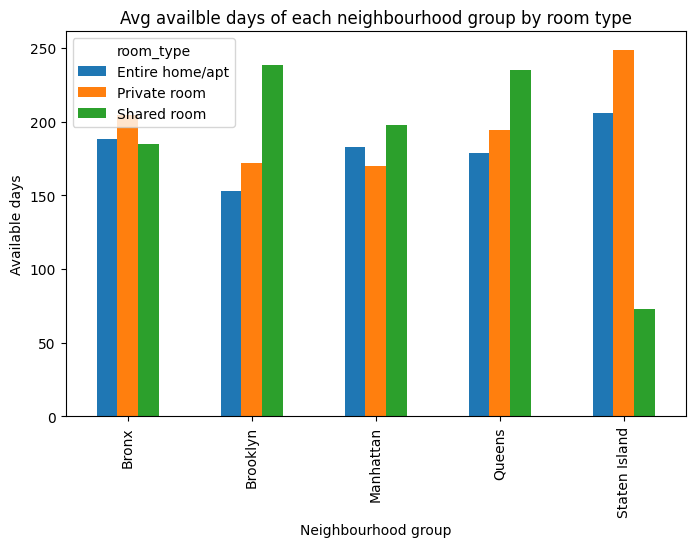

In [ ]:
#visualize the Data
Availability.plot(kind='bar')
plt.title('Avg availble days of each neighbourhood group by room type')
plt.xlabel('Neighbourhood group')
plt.ylabel("Available days")

From the above obseevation we found that Availabilty of Shared room is high in Brooklyn,then Queens,Manhattan,Bronx,Staten island respectively.

on the other hand in case of private room in staten island avialability is high then Bronx,Queens,Brooklyn,Manhattan respectively.

in case of entire home most avialibility found at Staten island,then Bronx,Manhattan,Queens,Brooklyn respectively

# Chart - 13 - Correlation Heatmap

In [ ]:
# Correlation Heatmap visualization code
Df = Airbnb_df[['price','minimum_nights','number_of_reviews','reviews_per_month','calculated_host_listings_count','availability_365','Daily_charge']]

In [ ]:
Corr_df = Df.corr()
Corr_df

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,Daily_charge
price,1.000000,0.042805,-0.047926,-0.050531,0.057462,0.081847,0.690937
minimum_nights,0.042805,1.000000,-0.080080,-0.124870,0.127962,0.144275,-0.105362
number_of_reviews,-0.047926,-0.080080,1.000000,0.589311,-0.072385,0.171975,-0.003772
reviews_per_month,-0.050531,-0.124870,0.589311,1.000000,-0.047322,0.163664,0.029196
calculated_host_listings_count,0.057462,0.127962,-0.072385,-0.047322,1.000000,0.225712,-0.026368
availability_365,0.081847,0.144275,0.171975,0.163664,0.225712,1.000000,0.034394
Daily_charge,0.690937,-0.105362,-0.003772,0.029196,-0.026368,0.034394,1.000000


<Axes: >

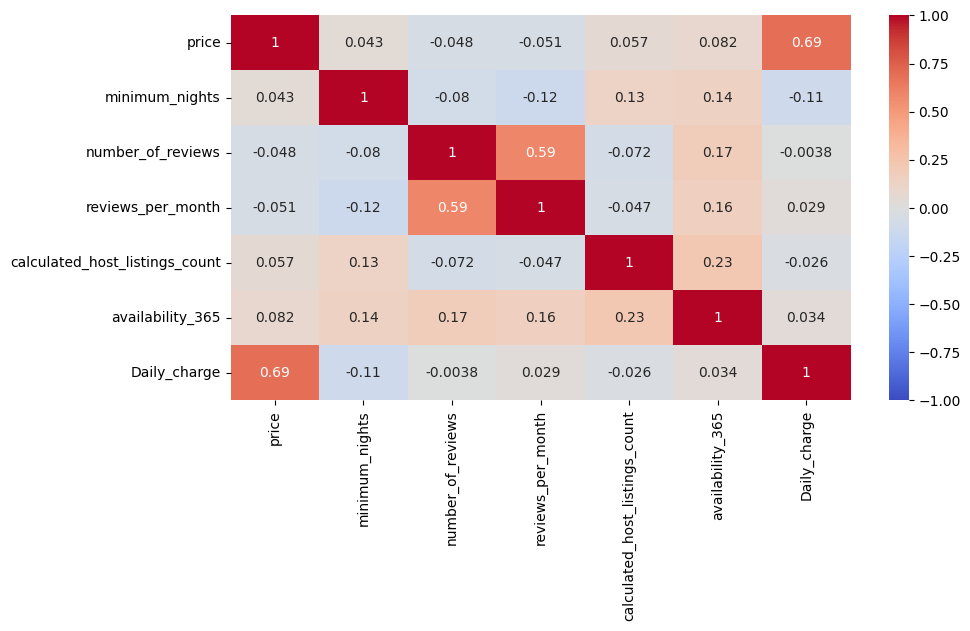

In [ ]:
plt.figure(figsize = (10,5))
sns.heatmap(Corr_df,vmin=-1,cmap='coolwarm',annot =True)

##### 2. What is/are the insight(s) found from the chart?

1.There is a weak positive correlation (0.057) between the price column and the calculated_host_listings_count column, which suggests that hosts with more listings tend to charge higher prices for their listings.

2.There is a moderate positive correlation (0.23) between the calculated_host_listings_count column and the availability_365 column, which suggests that hosts with more listings tend to have more days of availability in the next 365 days.

3.There is a strong positive correlation (0.59) between the number_of_reviews column and the reviews_per_month column, which suggests that listings with more total reviews tend to have more reviews per month.Answer Here

4.There is a weak positive correlation between (0.043) price and minimium_night_stay column. That means price does not vary much if you book more days to stay.

# 14 - Two way plot

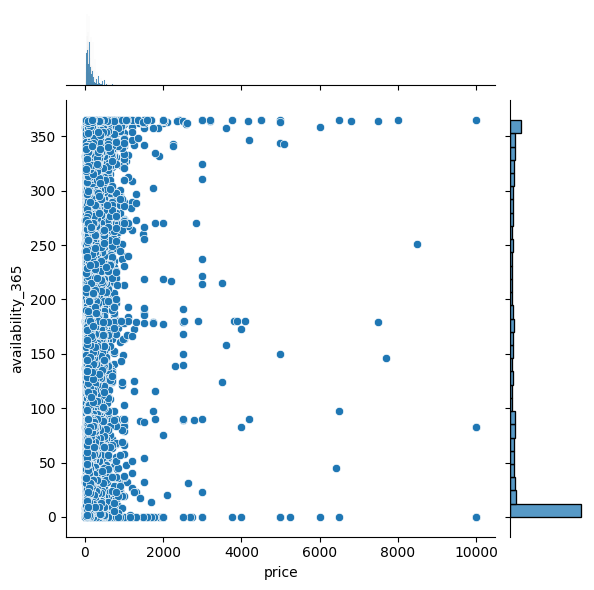

In [ ]:
sns.jointplot(x="price",y="availability_365",data = Df)

# Chart - 15 - Pair Plot

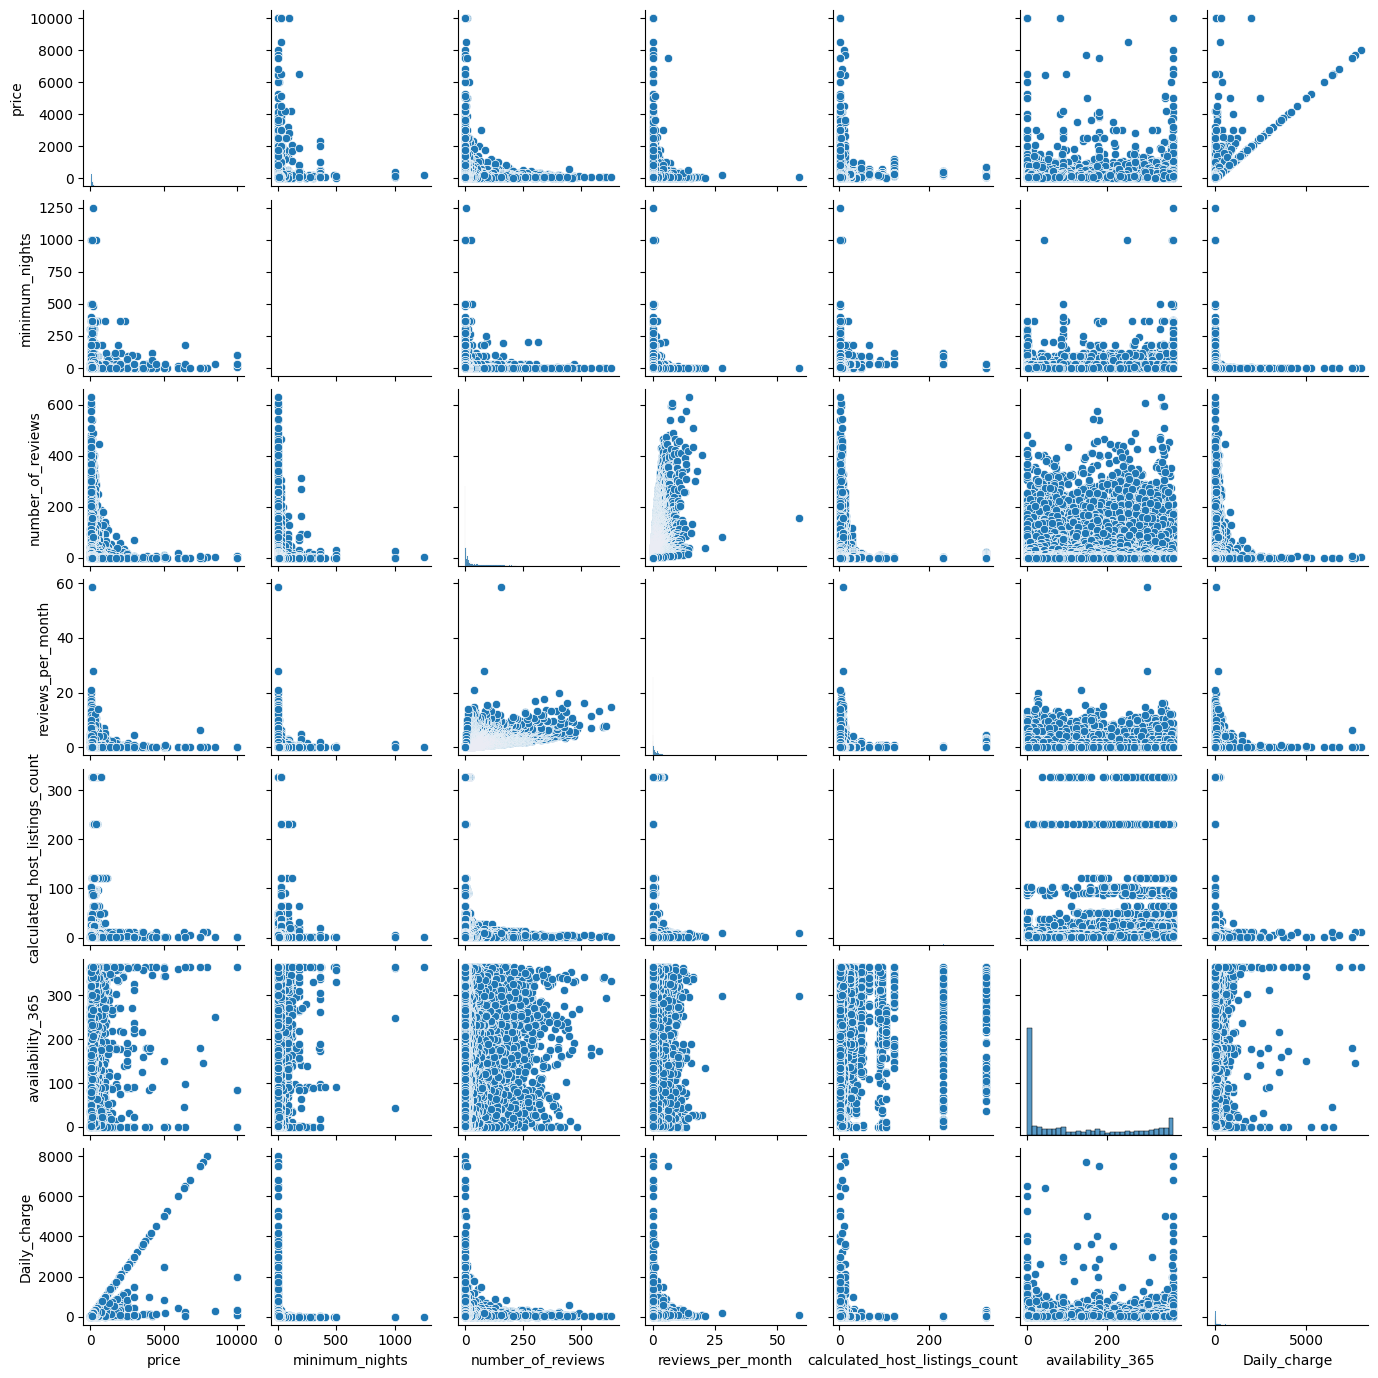

In [ ]:
# Pair Plot visualization code
sns.pairplot(Df,height = 2)
#plt.figure(figsize = (10,5))
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot consists of multiple scatterplots arranged in a grid, with each
scatterplot showing the relationship between two variables

It can be used to visualize relationships between multiple variables and to identify patterns in the data.

#  Buisness Conclusion

1.Manhattan and Brooklyn have the highest demand for Airbnb rentals, as evidenced by the large number of listings in these neighborhoods. This could make them attractive areas for hosts to invest in property.

2.Manhattan is world-famous for its parks, museums, buildings, town, liberty, gardens, markets, island and also its substantial number of tourists throughout the year ,it makes sense that demand and price both high.

3.Brooklyn comes in second with significant number of listings and cheaper prices as compared to the Manhattan: With most listings located in Williamsburg and Bedford Stuyvesant two neighborhoods strategically close to Manhattan tourists get the chance to enjoy both boroughs equally while spending less.

4.The average price of a listing  is higher at Manhattan compared to the outer boroughs. This could indicate that investing in property in Manhattan may be more lucrative for Airbnb rentals.

But Manhattan and Brooklyn have the largest number of hosts, indicating a high level of competition in these boroughs.

5.The data suggests that Airbnb rentals are primarily used for short-term stays, with relatively few listings requiring a minimum stay of 30 nights or more. Hosts may want to consider investing in property that can accommodate shorter stays in order to maximize their occupancy rate.

5.The majority of listings on Airbnb are for entire homes or apartments and also Private Rooms with relatively fewer listings for shared rooms. This suggests that travelers using Airbnb have a wide range of accommodation options to choose from, and hosts may want to consider investing in property that can accommodate multiple guests.

6.The data indicates that the availability of Airbnb rentals varies significantly across neighborhoods, with some neighborhoods having a high concentration of listings and others having relatively few.

7.The data indicates that there is a high level of competition among Airbnb hosts, with a small number of hosts dominating a large portion of the market. Hosts may want to consider investing in property in areas with relatively fewer listings in order to differentiate themselves from the competition.

8.The neighborhoods in Queens would have a higher average number of reviews, as they are likely to attract a lot of tourists or visitors who are passing through the area. The proximity  could make these neighborhoods a convenient and appealing place to stay for travelers for short-term stay with spending less money because The price distribution is high in Manhattan and Brooklyn.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***